# Mô hình Phân loại Mức độ Phù hợp giữa Ứng viên và Công việc (v4.1 - Đã sửa lỗi)

Mô hình này dự đoán liệu một ứng viên có phù hợp (HIGH) hay không phù hợp (LOW) với một tin tuyển dụng. Phiên bản này được cải tiến bằng cách:
1.  **Làm sạch dữ liệu rác** (Garbage In, Garbage Out).
2.  **Giảm số chiều** để chống học vẹt (Curse of Dimensionality).
3.  Sử dụng **Cosine Similarity** như một feature.
4.  Tinh chỉnh tham số cho mô hình `XGBoost` bằng `RandomizedSearchCV`.

---

## 🎯 Mục tiêu
Xây dựng một mô hình **Binary Classification** hiệu suất cao, có khả năng khái quát hóa tốt.

## 🛠 Phương pháp tiếp cận
1. **Đọc và Làm sạch dữ liệu**: Tải dữ liệu từ `data.csv` và loại bỏ các bản ghi vô nghĩa.
2. **Tiền xử lý & NLP**: Sử dụng `underthesea` để xử lý tiếng Việt.
3. **Feature Engineering & Dimensionality Reduction**:
    - Vector hóa văn bản với `max_features` được giảm đáng kể (từ 2000 -> 200).
    - Tính **Cosine Similarity** giữa vector ứng viên và công việc.
    - Kết hợp các features thành một ma trận đặc trưng cuối cùng.
4. **Huấn luyện & Tinh chỉnh**:
    - Sử dụng `RandomizedSearchCV` để tìm bộ tham số tốt nhất cho `XGBoost`.
    - Huấn luyện và so sánh với các mô hình cơ sở khác.
5. **Đánh giá & Lưu trữ**: So sánh các mô hình và lưu lại mô hình/vectorizer tốt nhất.

---

## 📋 Cấu trúc Notebook
1. **Phần 1**: Giới thiệu & Mục tiêu.
2. **Phần 2**: Load và Chuẩn bị dữ liệu.
3. **Phần 3**: Tiền xử lý dữ liệu & NLP.
4. **Phần 4**: Feature Engineering & Vectorization.
5. **Phần 5**: Huấn luyện, Tinh chỉnh và Đánh giá Mô hình.
6. **Phần 6**: Lưu và Tải mô hình.


# Phần 2: LOAD VÀ CHUẨN BỊ DỮ LIỆU


## 2.1. Import thư viện cần thiết

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
import warnings
import re
from underthesea import word_tokenize
import joblib
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style("whitegrid")


## 2.2. Load và Làm sạch dữ liệu

In [48]:
# Load dữ liệu từ một file CSV duy nhất
try:
    df = pd.read_csv("../data/csv_data/data.csv")
    print(f"Tải dữ liệu thành công! Shape ban đầu: {df.shape}")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file data.csv tại '../data/csv_data/data.csv'")
    df = pd.DataFrame()

# **BƯỚC 1: LÀM SẠCH DỮ LIỆU RÁC (GARBAGE IN, GARBAGE OUT)**
# Loại bỏ các hàng có job_post_description là 'undefined' hoặc job_post_title rỗng.
initial_rows = len(df)
df = df[df['job_post_description'] != 'undefined']
df = df[df['job_post_title'].str.strip() != '']
df.dropna(subset=['job_post_title', 'job_post_description'], inplace=True)

print(f"Đã loại bỏ {initial_rows - len(df)} hàng dữ liệu rác.")
print(f"Shape sau khi làm sạch: {df.shape}")


# Chuyển đổi nhãn dạng chuỗi ('HIGH'/'LOW') sang dạng số (1/0)
df['match'] = df['match'].map({'HIGH': 1, 'LOW': 0})

# Xử lý các giá trị NaN còn lại trong cột match (nếu có)
df.dropna(subset=['match'], inplace=True)
df['match'] = df['match'].astype(int)


df_model = df.copy()
df_model.head()



Tải dữ liệu thành công! Shape ban đầu: (282, 10)
Đã loại bỏ 93 hàng dữ liệu rác.
Shape sau khi làm sạch: (189, 10)


,candidate_summary,candidate_education,candidate_skills,job_post_title,job_post_description,job_post_industry,job_post_type,job_post_level,job_post_skills,match
2,Nhân sự tuyển dụng IT.,Cử nhân Quản trị kinh doanh,ReactJS Class Management Creativity Cyber Security MySQL Revit Laravel Flask Angular Android Nod...,Lập trình viên Frontend React,Làm việc với React và TypeScript,Vật lý học,Thực tập,Nhân viên cấp thấp (Junior),NaN,0
4,"Kỹ sư phần mềm, làm việc với hệ thống lớn.",Đại học Khoa học Tự nhiên,Machine Learning ReactJS Class Management Python Creativity Cyber Security JavaScript MongoDB Fl...,Kỹ sư hệ thống,Yêu cầu kinh nghiệm 2 năm,Quy hoạch đô thị,Bán thời gian,Giám đốc học thuật / nghiên cứu (Academic Director),NaN,1
5,Nhân sự tuyển dụng IT.,Cử nhân Công nghệ thông tin,Python Creativity Revit MongoDB Laravel Digital Marketing Android Audit SQL Time Management Prob...,Kỹ sư AI,"Môi trường năng động, trẻ trung",Thiết kế công nghiệp,Bán thời gian,Luật sư (Lawyer),NaN,1
6,Nhân sự tuyển dụng IT.,Cử nhân Công nghệ thông tin,Python Creativity Revit MongoDB Laravel Digital Marketing Android Audit SQL Time Management Prob...,Chuyên viên kiểm thử phần mềm,"Có kinh nghiệm Docker, Kubernetes",Công nghệ thực phẩm,Toàn thời gian,Hiệu trưởng / Giám đốc trung tâm (Principal),NaN,0
7,Sinh viên mới tốt nghiệp.,Tự học,Computer Vision Class Management Python Flask .NET/C# Spring Boot SQL Time Management Problem So...,Lập trình viên Backend Java,Hiểu biết về Machine Learning,Kỹ thuật điện tử - viễn thông,Làm việc từ xa,Giám đốc học thuật / nghiên cứu (Academic Director),NaN,0


# Phần 3: TIỀN XỬ LÝ DỮ LIỆU & NLP


## 3.1. Xử lý Missing Values

In [49]:
# Các cột văn bản cần được xử lý
text_cols = [
    'candidate_summary', 'candidate_education', 'candidate_skills',
    'job_post_title', 'job_post_description', 'job_post_industry',
    'job_post_type', 'job_post_level', 'job_post_skills'
]
# Điền giá trị rỗng cho các cột text
for col in text_cols:
    df_model[col] = df_model[col].fillna('')

print("Đã xử lý missing values.")


Đã xử lý missing values.


## 3.2. Xử lý NLP Tiếng Việt với `underthesea`

In [50]:
# Load stopwords
STOPWORDS_PATH = "../data/nlp/vietnamese-stopwords.txt"
try:
    with open(STOPWORDS_PATH, "r", encoding="utf-8") as f:
        vietnamese_stopwords = set(line.strip() for line in f if line.strip())
except FileNotFoundError:
    print("Không tìm thấy file stopwords, sẽ hoạt động không có stopwords.")
    vietnamese_stopwords = set()

# Hàm tiền xử lý văn bản
def preprocess_vietnamese_text(text):
    if not text or not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-zàáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵ0-9\s]', ' ', text)
    tokens = word_tokenize(text, format="text").split()
    return " ".join([t for t in tokens if t not in vietnamese_stopwords and not t.isdigit() and len(t) > 1])


## 3.3. Tạo Text Features tổng hợp

In [51]:
# Tạo cột text tổng hợp cho candidate
df_model['candidate_text'] = (
    df_model['candidate_summary'] + ' ' +
    df_model['candidate_education'] + ' ' +
    df_model['candidate_skills']
)

# Tạo cột text tổng hợp cho job
df_model['job_text'] = (
    df_model['job_post_title'] + ' ' +
    df_model['job_post_description'] + ' ' +
    df_model['job_post_industry'] + ' ' +
    df_model['job_post_type'] + ' ' +
    df_model['job_post_level'] + ' ' +
    df_model['job_post_skills']
)

# Áp dụng NLP
print("Đang tiền xử lý văn bản...")
df_model['candidate_text_processed'] = df_model['candidate_text'].apply(preprocess_vietnamese_text)
df_model['job_text_processed'] = df_model['job_text'].apply(preprocess_vietnamese_text)
print("Tiền xử lý văn bản hoàn tất.")


Đang tiền xử lý văn bản...
Tiền xử lý văn bản hoàn tất.


# Phần 4: FEATURE ENGINEERING & VECTORIZATION

In [52]:
## 4.1. Chia dữ liệu (Train-Test Split)

In [53]:
# Xác định features (X) và target (y)
X_data = df_model[['candidate_text_processed', 'job_text_processed']]
y_data = df_model['match']

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

print(f"Tập huấn luyện: {len(X_train)} mẫu")
print(f"Tập kiểm thử: {len(X_test)} mẫu")


Tập huấn luyện: 151 mẫu
Tập kiểm thử: 38 mẫu


## 4.2. Vectorization và tạo Feature Cosine Similarity

In [54]:
# **BƯỚC 2: GIẢM SỐ CHIỀU (DIMENSIONALITY REDUCTION)**
# Giảm mạnh max_features từ 2000 xuống 200 để phù hợp với tập dữ liệu nhỏ.
# Điều chỉnh min_df để không quá khắt khe.
tfidf_vectorizer = TfidfVectorizer(max_features=200, ngram_range=(1, 2), min_df=2, max_df=0.9)

# Fit vectorizer trên toàn bộ văn bản của tập train
all_train_text = pd.concat([X_train['candidate_text_processed'], X_train['job_text_processed']])
tfidf_vectorizer.fit(all_train_text)

# Hàm để tạo features
def create_features(X, vectorizer):
    vec_candidate = vectorizer.transform(X['candidate_text_processed'])
    vec_job = vectorizer.transform(X['job_text_processed'])

    # Tính cosine similarity theo từng hàng
    similarity = np.array([cosine_similarity(vec_candidate[i], vec_job[i])[0][0] for i in range(vec_candidate.shape[0])])
    similarity_feature = csr_matrix(similarity.reshape(-1, 1))

    # Kết hợp tất cả features
    return hstack([vec_candidate, vec_job, similarity_feature])

# Tạo features cho tập train và test
X_train_final = create_features(X_train, tfidf_vectorizer)
X_test_final = create_features(X_test, tfidf_vectorizer)

print("=== KÍCH THƯỚC MA TRẬN FEATURE CUỐI CÙNG ===")
print(f"Train matrix shape: {X_train_final.shape}")
print(f"Test matrix shape: {X_test_final.shape}")


=== KÍCH THƯỚC MA TRẬN FEATURE CUỐI CÙNG ===
Train matrix shape: (151, 401)
Test matrix shape: (38, 401)


# Phần 5: HUẤN LUYỆN, TINH CHỈNH VÀ ĐÁNH GIÁ MÔ HÌNH


### 5.1. Tinh chỉnh siêu tham số cho XGBoost bằng `RandomizedSearchCV`

In [55]:
# Định nghĩa không gian tham số
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Khởi tạo RandomizedSearchCV
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=30, # Giảm số lần thử để nhanh hơn với tập dữ liệu nhỏ
    scoring='accuracy',
    n_jobs=-1,
    cv=3,
    random_state=42,
    verbose=1
)

print("--- Bắt đầu tinh chỉnh tham số cho XGBoost ---")
random_search.fit(X_train_final, y_train)

print("\n--- Kết quả tinh chỉnh ---")
print(f"Bộ tham số tốt nhất: {random_search.best_params_}")
print(f"Độ chính xác tốt nhất trên tập validation: {random_search.best_score_:.4f}")

# Lấy ra mô hình XGBoost đã được tinh chỉnh
best_xgb = random_search.best_estimator_


--- Bắt đầu tinh chỉnh tham số cho XGBoost ---
Fitting 3 folds for each of 30 candidates, totalling 90 fits

--- Kết quả tinh chỉnh ---
Bộ tham số tốt nhất: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Độ chính xác tốt nhất trên tập validation: 0.5831


### 5.2. Huấn luyện và Đánh giá các mô hình

In [56]:
# Định nghĩa các mô hình, bao gồm cả XGBoost đã tinh chỉnh
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "XGBoost (Tuned)": best_xgb
}

results = {}
for name, model in models.items():
    print(f"--- Đang huấn luyện và đánh giá mô hình: {name} ---")
    if name != "XGBoost (Tuned)":
        model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['LOW', 'HIGH'], zero_division=0)
    results[name] = {'model': model, 'accuracy': accuracy, 'report': report, 'predictions': y_pred}

    print(f"Độ chính xác (Accuracy): {accuracy:.4f}")
    print("Báo cáo phân loại:\n", report)


--- Đang huấn luyện và đánh giá mô hình: Logistic Regression ---
Độ chính xác (Accuracy): 0.4474
Báo cáo phân loại:
               precision    recall  f1-score   support

         LOW       0.50      0.33      0.40        21
        HIGH       0.42      0.59      0.49        17

    accuracy                           0.45        38
   macro avg       0.46      0.46      0.44        38
weighted avg       0.46      0.45      0.44        38

--- Đang huấn luyện và đánh giá mô hình: Random Forest ---
Độ chính xác (Accuracy): 0.3684
Báo cáo phân loại:
               precision    recall  f1-score   support

         LOW       0.42      0.38      0.40        21
        HIGH       0.32      0.35      0.33        17

    accuracy                           0.37        38
   macro avg       0.37      0.37      0.37        38
weighted avg       0.37      0.37      0.37        38

--- Đang huấn luyện và đánh giá mô hình: XGBoost (Tuned) ---
Độ chính xác (Accuracy): 0.4211
Báo cáo phân loại:
      

### 5.3. So sánh và Lựa chọn mô hình cuối cùng

=== MÔ HÌNH CUỐI CÙNG TỐT NHẤT: Logistic Regression ===
Độ chính xác: 0.4474
Báo cáo phân loại chi tiết:
               precision    recall  f1-score   support

         LOW       0.50      0.33      0.40        21
        HIGH       0.42      0.59      0.49        17

    accuracy                           0.45        38
   macro avg       0.46      0.46      0.44        38
weighted avg       0.46      0.45      0.44        38



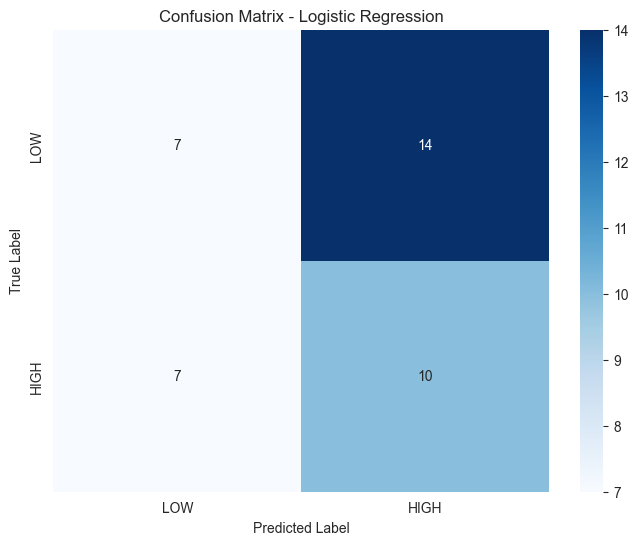

In [57]:
best_model_name = max(results, key=lambda name: results[name]['accuracy'])
best_model_info = results[best_model_name]
best_model = best_model_info['model']

print(f"=== MÔ HÌNH CUỐI CÙNG TỐT NHẤT: {best_model_name} ===")
print(f"Độ chính xác: {best_model_info['accuracy']:.4f}")
print("Báo cáo phân loại chi tiết:\n", best_model_info['report'])

cm = confusion_matrix(y_test, best_model_info['predictions'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['LOW', 'HIGH'], yticklabels=['LOW', 'HIGH'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


# Phần 6: LƯU VÀ TẢI MÔ HÌNH

In [58]:
model_dir = "../saved_models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "suitability_model_v4.joblib")
vectorizer_path = os.path.join(model_dir, "tfidf_vectorizer_v4.joblib")

joblib.dump(best_model, model_path)
print(f"Mô hình '{best_model_name}' đã được lưu tại: {model_path}")
joblib.dump(tfidf_vectorizer, vectorizer_path)
print(f"Vectorizer đã được lưu tại: {vectorizer_path}")


Mô hình 'Logistic Regression' đã được lưu tại: ../saved_models\suitability_model_v4.joblib
Vectorizer đã được lưu tại: ../saved_models\tfidf_vectorizer_v4.joblib


## 6.1. Hướng dẫn sử dụng mô hình đã lưu

In [59]:
loaded_model = joblib.load(model_path)
loaded_vectorizer = joblib.load(vectorizer_path)

sample_candidate = {
    "summary": "Kỹ sư phần mềm 5 năm kinh nghiệm Java, Spring Boot.",
    "education": "Đại học Bách Khoa Hà Nội",
    "skills": "Java, Spring Boot, Microservices"
}
sample_job = {
    "title": "Senior Java Developer",
    "description": "Tuyển dụng lập trình viên .Net nhiều kinh nghiệm.",
    "industry": "Công nghệ thông tin",
    "type": "Toàn thời gian",
    "level": "Senior",
    "skills": "Python, .Net, SQL"
}

def predict_suitability_v4(candidate_info, job_info, model, vectorizer):
    candidate_text = " ".join(candidate_info.values())
    job_text = " ".join(job_info.values())

    processed_candidate_text = preprocess_vietnamese_text(candidate_text)
    processed_job_text = preprocess_vietnamese_text(job_text)

    X_sample = pd.DataFrame([{'candidate_text_processed': processed_candidate_text, 'job_text_processed': processed_job_text}])
    features = create_features(X_sample, vectorizer)

    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0]

    label = 'HIGH' if prediction == 1 else 'LOW'
    confidence = probability[prediction]

    return label, confidence

predicted_label, confidence_score = predict_suitability_v4(sample_candidate, sample_job, loaded_model, loaded_vectorizer)

print("\n=== DEMO DỰ ĐOÁN V4 ===")
print(f"Kết quả dự đoán: {predicted_label} (Độ tự tin: {confidence_score:.2%})")



=== DEMO DỰ ĐOÁN V4 ===
Kết quả dự đoán: HIGH (Độ tự tin: 53.36%)
